# Projeto Integrador IV-A

## Pipeline de Big Data para Análise de Matrículas

**Aluna:** Ana Gabriela M. Santana

**Contexto:** Escola Particular - Dados de matrículas (2022-2025)

**Objetivo:** Construir uma pipeline de dados em nuvem (Google Colab + Apache Spark) para coletar, processar e analisar dados de matrículas, gerando métricas de gestão e previsão para 2026.

# Configuração do Spark

In [63]:
# ============================================================================
# CONFIGURAÇÃO DO APACHE SPARK NO GOOGLE COLAB
# ============================================================================

print("="*80)
print("CONFIGURAÇÃO DO AMBIENTE SPARK")
print("="*80)

# instalar java
!apt-get install openjdk-11-jdk-headless -qq > /dev/null

# baixar spark
!wget -q https://archive.apache.org/dist/spark/spark-3.4.1/spark-3.4.1-bin-hadoop3.tgz
!tar xf spark-3.4.1-bin-hadoop3.tgz

# instalar findspark
!pip install -q findspark

import os
import findspark

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.4.1-bin-hadoop3"

findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("PipelineMatriculas") \
    .master("local[*]") \
    .config("spark.driver.memory","2g") \
    .getOrCreate()

print("Spark configurado com sucesso")
print("Versão do Spark:", spark.version)

CONFIGURAÇÃO DO AMBIENTE SPARK
Spark configurado com sucesso
Versão do Spark: 3.4.1


# Entendimento do projeto

In [64]:
# ============================================================================
# 1. ENTENDIMENTO DO NEGÓCIO
# ============================================================================

print("="*80)
print("1. ENTENDIMENTO DO NEGÓCIO")
print("="*80)

print("""
CONTEXTO DO PROJETO:

A escola particular enfrenta desafios na gestão de matrículas e retenção de
alunos. Atualmente, os dados de matrículas, rematrículas, procuras e
cancelamentos são registrados manualmente em planilhas, dificultando a
análise estratégica e a tomada de decisão.

PROBLEMA DE NEGÓCIO:

Como processar grandes volumes de dados de matrículas de forma eficiente e
extrair insights que auxiliem a gestão escolar na retenção de alunos?

OBJETIVO DO PROJETO:

Construir uma pipeline de dados distribuída (Big Data) capaz de coletar,
processar e analisar dados históricos de matrículas (2022-2025), gerando
métricas de gestão e previsão para 2026.

STAKEHOLDERS:

- Direção da escola
- Coordenação administrativa
- Equipe de marketing (para campanhas)
- Equipe pedagógica

BENEFÍCIOS ESPERADOS:

1. Identificação dos períodos de maior procura
2. Otimização de campanhas de matrícula
3. Redução da taxa de cancelamento
4. Planejamento estratégico baseado em dados

METAS DE SUCESSO:

- Pipeline funcional processando dados de 4 anos (2022-2025)
- Geração automática de métricas (taxa de conversão, cancelamento)
- Previsão de matrículas para 2026 com erro controlado
""")

1. ENTENDIMENTO DO NEGÓCIO

CONTEXTO DO PROJETO:

A escola particular enfrenta desafios na gestão de matrículas e retenção de
alunos. Atualmente, os dados de matrículas, rematrículas, procuras e
cancelamentos são registrados manualmente em planilhas, dificultando a
análise estratégica e a tomada de decisão.

PROBLEMA DE NEGÓCIO:

Como processar grandes volumes de dados de matrículas de forma eficiente e
extrair insights que auxiliem a gestão escolar na retenção de alunos?

OBJETIVO DO PROJETO:

Construir uma pipeline de dados distribuída (Big Data) capaz de coletar,
processar e analisar dados históricos de matrículas (2022-2025), gerando
métricas de gestão e previsão para 2026.

STAKEHOLDERS:

- Direção da escola
- Coordenação administrativa
- Equipe de marketing (para campanhas)
- Equipe pedagógica

BENEFÍCIOS ESPERADOS:

1. Identificação dos períodos de maior procura
2. Otimização de campanhas de matrícula
3. Redução da taxa de cancelamento
4. Planejamento estratégico baseado em dado

# Upload dos arquivos

In [65]:
# ============================================================================
# 2. INGESTÃO DE DADOS
# ============================================================================

print("="*80)
print("2. INGESTÃO DE DADOS - UPLOAD DOS ARQUIVOS CSV")
print("="*80)

from google.colab import files

print("""
Envie os seguintes arquivos (nomes exatos):
  - dados_matriculas_escola(2022).csv
  - dados_matriculas_escola(2023).csv
  - dados_matriculas_escola(2024).csv
  - dados_matriculas_escola(2025).csv

Os arquivos devem ter as colunas:
  mes;novas_matriculas;rematriculas;procuras_matricula;cancelamentos
""")

uploaded = files.upload()

print(f"\nArquivos recebidos: {list(uploaded.keys())}")

2. INGESTÃO DE DADOS - UPLOAD DOS ARQUIVOS CSV

Envie os seguintes arquivos (nomes exatos):
  - dados_matriculas_escola(2022).csv
  - dados_matriculas_escola(2023).csv
  - dados_matriculas_escola(2024).csv
  - dados_matriculas_escola(2025).csv

Os arquivos devem ter as colunas:
  mes;novas_matriculas;rematriculas;procuras_matricula;cancelamentos



Saving dados_matriculas_escola(2022).csv to dados_matriculas_escola(2022) (6).csv
Saving dados_matriculas_escola(2023).csv to dados_matriculas_escola(2023) (6).csv
Saving dados_matriculas_escola(2024).csv to dados_matriculas_escola(2024) (6).csv
Saving dados_matriculas_escola(2025).csv to dados_matriculas_escola(2025) (5).csv

Arquivos recebidos: ['dados_matriculas_escola(2022) (6).csv', 'dados_matriculas_escola(2023) (6).csv', 'dados_matriculas_escola(2024) (6).csv', 'dados_matriculas_escola(2025) (5).csv']


# Leitura e união dos dados

In [66]:
# ============================================================================
# LEITURA DOS CSV
# ============================================================================

print("="*80)
print("LEITURA DOS ARQUIVOS")
print("="*80)

nomes_arquivos = {
    2022: "dados_matriculas_escola(2022).csv",
    2023: "dados_matriculas_escola(2023).csv",
    2024: "dados_matriculas_escola(2024).csv",
    2025: "dados_matriculas_escola(2025).csv"
}

dataframes = []

# Importar funcoes necessarias do PySpark
from pyspark.sql.functions import col, regexp_replace, lit

actual_uploaded_files = list(uploaded.keys())

for ano, nome_esperado in nomes_arquivos.items():
    found_file_key = None
    for uploaded_key in actual_uploaded_files:
        # Check if the expected name (without .csv) is a prefix of the uploaded key
        # and if the uploaded key ends with .csv. This handles suffixes like ' (3).csv'
        if uploaded_key.startswith(nome_esperado.replace('.csv', '')) and uploaded_key.endswith('.csv'):
            found_file_key = uploaded_key
            break

    if found_file_key:
        print(f"Lendo {found_file_key} para o ano {ano}...")
        df = spark.read.csv(
            found_file_key, # Use the actual uploaded file key
            header=True,
            inferSchema=True,
            sep=";",
            encoding="latin1"
        )

        df = df.withColumn("mes", regexp_replace(col("mes"), " ", ""))
        df = df.withColumn("ano", lit(ano)) # Use lit(ano) for literal column value

        dataframes.append(df)
        print(f"{found_file_key} carregado")

    else:
        print(f"{nome_esperado} nao encontrado entre os arquivos carregados.")
        print(f"Arquivos disponiveis apos upload: {', '.join(actual_uploaded_files)}")

from functools import reduce

# Verificar se a lista de dataframes nao esta vazia antes de aplicar reduce
if dataframes:
    df_total = reduce(lambda a,b: a.union(b), dataframes)

    print("Total de registros:", df_total.count())
    df_total.show(10)
else:
    print("Nenhum arquivo CSV foi carregado com sucesso. 'df_total' nao sera criado.")
    df_total = None # Define df_total as None to prevent NameError in subsequent cells

LEITURA DOS ARQUIVOS
Lendo dados_matriculas_escola(2022) (6).csv para o ano 2022...
dados_matriculas_escola(2022) (6).csv carregado
Lendo dados_matriculas_escola(2023) (6).csv para o ano 2023...
dados_matriculas_escola(2023) (6).csv carregado
Lendo dados_matriculas_escola(2024) (6).csv para o ano 2024...
dados_matriculas_escola(2024) (6).csv carregado
Lendo dados_matriculas_escola(2025) (5).csv para o ano 2025...
dados_matriculas_escola(2025) (5).csv carregado
Total de registros: 48
+---------+----------------+------------+------------------+-------------+----+
|      mes|novas_matriculas|rematriculas|procuras_matricula|cancelamentos| ano|
+---------+----------------+------------+------------------+-------------+----+
|  Janeiro|               5|          18|                 7|            2|2022|
|Fevereiro|               4|           8|                 9|            3|2022|
|    Março|               2|           1|                 2|            1|2022|
|    Abril|               1|    

# Limpeza e transformação dos dados

In [67]:
# ============================================================================
# 4. LIMPEZA E TRANSFORMAÇÃO DOS DADOS
# ============================================================================

print("="*80)
print("4. LIMPEZA E TRANSFORMAÇÃO")
print("="*80)

from pyspark.sql.functions import create_map, lit, col, when, round
from pyspark.sql.types import IntegerType

# 1. Substituir valores nulos por 0
print("\n1. Tratando valores nulos...")
colunas_num = ["novas_matriculas", "rematriculas", "procuras_matricula", "cancelamentos"]
for c in colunas_num:
    df_total = df_total.withColumn(c, when(col(c).isNull(), 0).otherwise(col(c)))

# 2. Calcular total de alunos no fim do mês
print("2. Calculando total de alunos por mes...")
df_total = df_total.withColumn(
    "total_alunos_fim_mes",
    col("novas_matriculas") + col("rematriculas") - col("cancelamentos")
)

# 3. Calcular taxa de conversão (procura -> matrícula)
print("3. Calculando taxa de conversao...")
df_total = df_total.withColumn(
    "taxa_conversao",
    when(col("procuras_matricula") > 0,
         round((col("novas_matriculas") / col("procuras_matricula")) * 100, 2)
    ).otherwise(0)
)

# 4. Criar ordem numérica dos meses
print("4. Criando ordenacao dos meses...")
ordem_meses = {
    "Janeiro": 1, "Fevereiro": 2, "Março": 3, "Abril": 4,
    "Maio": 5, "Junho": 6, "Julho": 7, "Agosto": 8,
    "Setembro": 9, "Outubro": 10, "Novembro": 11, "Dezembro": 12
}

# Correção: Use uma list comprehension para achatar os itens do dicionário
mapping_list = [item for pair in ordem_meses.items() for item in pair]
mapping_expr = create_map([lit(x) for x in mapping_list])
df_total = df_total.withColumn(
    "mes_num",
    mapping_expr[col("mes")].cast(IntegerType())
)

# 5. Ordenar por ano e mês
df_total = df_total.orderBy("ano", "mes_num")

print("\nDados apos limpeza e transformacao:")
df_total.show(20)

# Verificar meses não mapeados
null_meses = df_total.filter(col("mes_num").isNull()).select("mes").distinct().collect()
if null_meses:
    print(f"\nAtencao: Meses nao mapeados encontrados: {null_meses}")
else:
    print("\nTodos os meses foram mapeados corretamente")


4. LIMPEZA E TRANSFORMAÇÃO

1. Tratando valores nulos...
2. Calculando total de alunos por mes...
3. Calculando taxa de conversao...
4. Criando ordenacao dos meses...

Dados apos limpeza e transformacao:
+---------+----------------+------------+------------------+-------------+----+--------------------+--------------+-------+
|      mes|novas_matriculas|rematriculas|procuras_matricula|cancelamentos| ano|total_alunos_fim_mes|taxa_conversao|mes_num|
+---------+----------------+------------+------------------+-------------+----+--------------------+--------------+-------+
|  Janeiro|               5|          18|                 7|            2|2022|                  21|         71.43|      1|
|Fevereiro|               4|           8|                 9|            3|2022|                   9|         44.44|      2|
|    Março|               2|           1|                 2|            1|2022|                   2|         100.0|      3|
|    Abril|               1|           0|           

# Análises de metricas

In [68]:
# ============================================================================
# 5. ANÁLISE DE MÉTRICAS E INDICADORES
# ============================================================================

print("="*80)
print("5. ANALISE DE METRICAS E INDICADORES")
print("="*80)

from pyspark.sql.functions import avg, sum, col, round

# 1. Média de alunos ativos por ano
print("\nMETRICA 1: MEDIA DE ALUNOS ATIVOS POR ANO")
print("-"*50)
media_alunos = df_total.groupBy("ano").agg(
    round(avg("total_alunos_fim_mes"), 0).alias("media_alunos_ativos_mensal")
)
media_alunos.show()

# 2. Taxa de cancelamento por ano
print("\nMETRICA 2: TAXA DE CANCELAMENTO POR ANO (%)")
print("-"*50)
taxa_cancelamento = df_total.groupBy("ano").agg(
    round((sum("cancelamentos") / sum("total_alunos_fim_mes") * 100), 2).alias("taxa_cancelamento")
)
taxa_cancelamento.show()

# 3. Meses com mais matrículas
print("\nMETRICA 3: MESES COM MAIS MATRICULAS (HISTORICO 2022-2025)")
print("-"*50)
melhores_meses = df_total.groupBy("mes").agg(
    sum("novas_matriculas").alias("total_matriculas")
).orderBy(col("total_matriculas").desc())
melhores_meses.show(12)

# 4. Taxa de conversão por ano
print("\nMETRICA 4: TAXA DE CONVERSAO PROCURA -> MATRICULA (%)")
print("-"*50)
conversao = df_total.groupBy("ano").agg(
    round(avg("taxa_conversao"), 2).alias("taxa_conversao_media")
).orderBy("ano")
conversao.show()

# 5. Evolução anual das matrículas
print("\nMETRICA 5: EVOLUCAO ANUAL DAS MATRICULAS")
print("-"*50)
evolucao = df_total.groupBy("ano").agg(
    sum("novas_matriculas").alias("total_novas_matriculas")
).orderBy("ano")
evolucao.show()

5. ANALISE DE METRICAS E INDICADORES

METRICA 1: MEDIA DE ALUNOS ATIVOS POR ANO
--------------------------------------------------
+----+--------------------------+
| ano|media_alunos_ativos_mensal|
+----+--------------------------+
|2022|                      12.0|
|2023|                      14.0|
|2024|                      15.0|
|2025|                      16.0|
+----+--------------------------+


METRICA 2: TAXA DE CANCELAMENTO POR ANO (%)
--------------------------------------------------
+----+-----------------+
| ano|taxa_cancelamento|
+----+-----------------+
|2022|            17.24|
|2023|            13.69|
|2024|            14.29|
|2025|             8.33|
+----+-----------------+


METRICA 3: MESES COM MAIS MATRICULAS (HISTORICO 2022-2025)
--------------------------------------------------
+---------+----------------+
|      mes|total_matriculas|
+---------+----------------+
| Dezembro|              90|
| Novembro|              77|
|  Outubro|              42|
|   Agosto|   

# Visualização

6. VISUALIZACOES

GERANDO GRAFICOS...


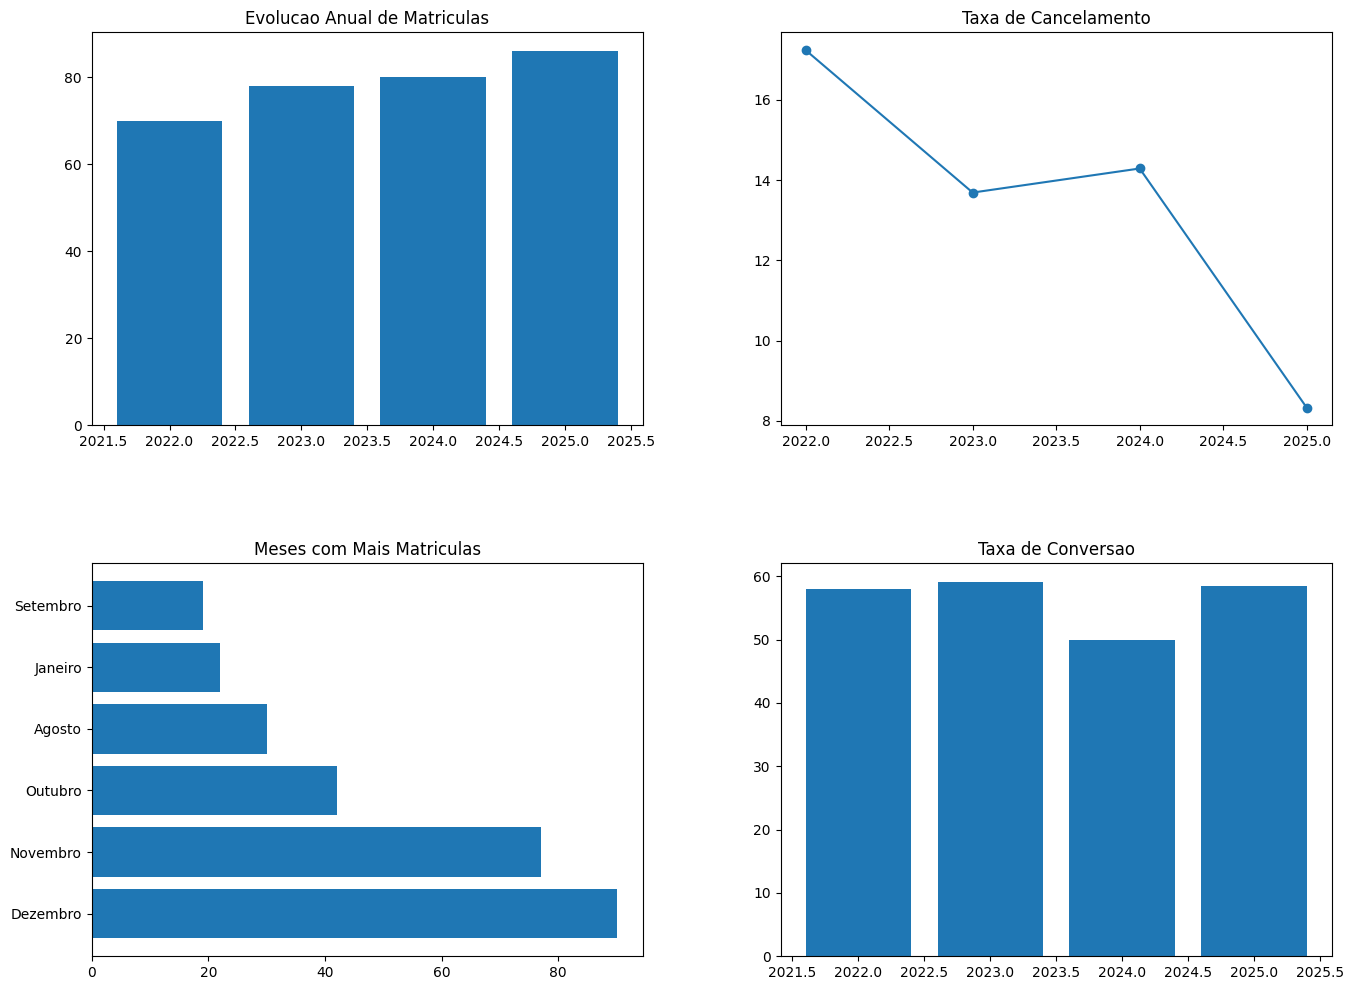

In [74]:
# ============================================================================
# 6. VISUALIZAÇÕES EXPLORATÓRIAS
# ============================================================================

print("="*80)
print("6. VISUALIZACOES")
print("="*80)

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

print("\nGERANDO GRAFICOS...")

# Converter para pandas
evolucao_pd = evolucao.orderBy("ano").toPandas()
cancel_pd = taxa_cancelamento.orderBy("ano").toPandas()
melhores_pd = melhores_meses.orderBy("total_matriculas", ascending=False).limit(6).toPandas()
conv_pd = conversao.orderBy("ano").toPandas()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Evolução anual
ax1 = axes[0,0]
ax1.bar(evolucao_pd["ano"], evolucao_pd["total_novas_matriculas"])
ax1.set_title("Evolucao Anual de Matriculas")

# Cancelamento
ax2 = axes[0,1]
ax2.plot(cancel_pd["ano"], cancel_pd["taxa_cancelamento"], marker="o")
ax2.set_title("Taxa de Cancelamento")

# Meses com mais matrículas
ax3 = axes[1,0]
ax3.barh(melhores_pd["mes"], melhores_pd["total_matriculas"])
ax3.set_title("Meses com Mais Matriculas")

# Conversão
ax4 = axes[1,1]
ax4.bar(conv_pd["ano"], conv_pd["taxa_conversao_media"])
ax4.set_title("Taxa de Conversao")

plt.subplots_adjust(hspace=0.35, wspace=0.25)


# Previsão para 2026

PREVISAO DE MATRICULAS PARA 2026

Dados historicos utilizados para previsao:
 ano  total_matriculas_ano
2022                    70
2023                    78
2024                    80
2025                    86

PREVISAO: 91 novas matriculas em 2026
Crescimento estimado: +5 matriculas em relacao a 2025


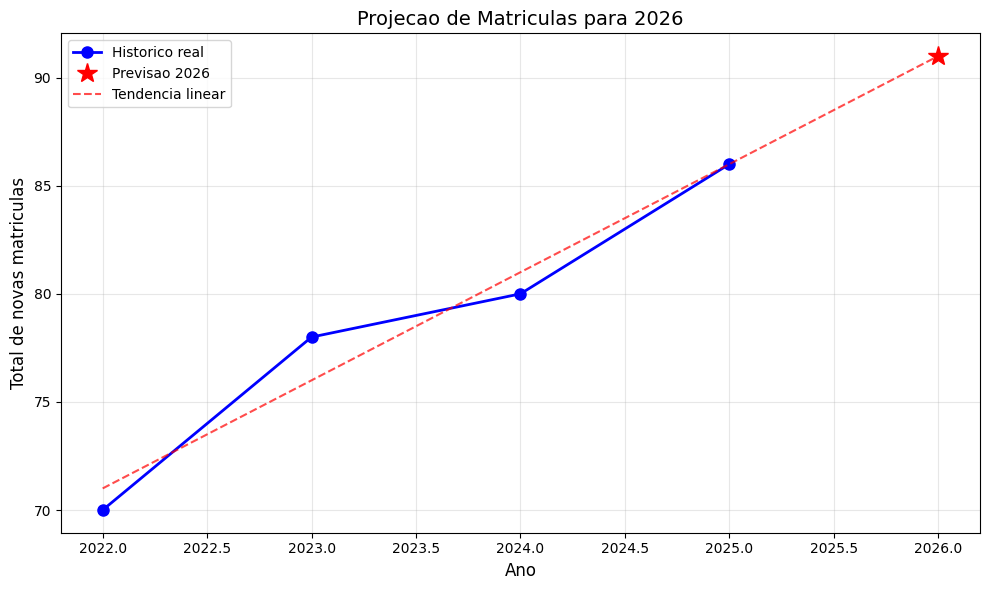


EQUACAO DA TENDENCIA:
Matriculas = 5.0 * Ano + -10039.0
R² = 0.954


In [70]:
# ============================================================================
# REVISÃO PARA 2026 (REGRESSÃO LINEAR)
# ============================================================================

print("="*80)
print("PREVISAO DE MATRICULAS PARA 2026")
print("="*80)

# Agregar por ano para previsão
from pyspark.sql.functions import sum as spark_sum_alias # Alias to avoid conflict if `sum` is a built-in function for other purpose
df_agregado = df_total.groupBy("ano").agg(
    spark_sum_alias("novas_matriculas").alias("total_matriculas_ano")
).orderBy("ano")

# Converter para Pandas
df_previsao = df_agregado.toPandas()

print("\nDados historicos utilizados para previsao:")
print(df_previsao.to_string(index=False))

from sklearn.linear_model import LinearRegression
import numpy as np

# Regressão linear
X = df_previsao["ano"].values.reshape(-1, 1)
y = df_previsao["total_matriculas_ano"].values

modelo = LinearRegression()
modelo.fit(X, y)

# Previsão para 2026
previsao_2026 = modelo.predict([[2026]])[0]

print(f"\nPREVISAO: {int(previsao_2026)} novas matriculas em 2026")

# Calcular crescimento
if 2025 in df_previsao["ano"].values:
    matriculas_2025 = df_previsao[df_previsao["ano"] == 2025]["total_matriculas_ano"].values[0]
    crescimento = int(previsao_2026 - matriculas_2025)
    print(f"Crescimento estimado: +{crescimento} matriculas em relacao a 2025")

# Gráfico da projeção
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(df_previsao["ano"], df_previsao["total_matriculas_ano"], 'bo-', linewidth=2, markersize=8, label="Historico real")
plt.plot(2026, previsao_2026, 'r*', markersize=15, label="Previsao 2026")

# Linha de tendência
anos_tendencia = np.array([[2022], [2023], [2024], [2025], [2026]])
plt.plot(anos_tendencia, modelo.predict(anos_tendencia), 'r--', alpha=0.7, label="Tendencia linear")

plt.xlabel("Ano", fontsize=12)
plt.ylabel("Total de novas matriculas", fontsize=12)
plt.title("Projecao de Matriculas para 2026", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Equação da reta
print(f"\nEQUACAO DA TENDENCIA:")
print(f"Matriculas = {modelo.coef_[0]:.1f} * Ano + {modelo.intercept_:.1f}")
print(f"R² = {modelo.score(X, y):.3f}")

# Relatório final

In [71]:
# ============================================================================
# RELATÓRIO FINAL
# ============================================================================

print("="*80)
print("RELATORIO FINAL - PIPELINE DE BIG DATA")
print("="*80)

from pyspark.sql.functions import sum as spark_sum, avg as spark_avg

# Coletar totais (forçando recálculo)
total_matriculas = df_total.agg(spark_sum("novas_matriculas")).collect()[0][0]
total_cancelamentos = df_total.agg(spark_sum("cancelamentos")).collect()[0][0]
total_procuras = df_total.agg(spark_sum("procuras_matricula")).collect()[0][0]

# Calcular totais por ano para conferência
print("\n--- VERIFICACAO DOS DADOS ---")
df_total.groupBy("ano").agg(
    spark_sum("cancelamentos").alias("cancelamentos_ano")
).orderBy("ano").show()

print(f"\n--- TOTAIS GERAIS ---")
print(f"Total de matriculas: {total_matriculas}")
print(f"Total de cancelamentos: {total_cancelamentos}")
print(f"Total de procuras: {total_procuras}")

# Calcular taxas medias
taxa_cancelamento_media = df_total.groupBy("ano").agg(
    (spark_sum("cancelamentos") / spark_sum("total_alunos_fim_mes") * 100).alias("taxa")
).agg(spark_avg("taxa")).collect()[0][0]

taxa_conversao_media = df_total.groupBy("ano").agg(
    spark_avg("taxa_conversao").alias("media")
).agg(spark_avg("media")).collect()[0][0]

print("\n" + "="*80)
print("RESUMO EXECUTIVO")
print("="*80)
print(f"""
Periodo analisado: 2022 a 2025
Total de novas matriculas: {total_matriculas}
Total de cancelamentos: {total_cancelamentos}
Total de procuras: {total_procuras}
Taxa media de retencao: {100 - taxa_cancelamento_media:.2f}%
Taxa media de conversao: {taxa_conversao_media:.2f}%
Previsao de matriculas 2026: {int(previsao_2026)}

CONCLUSOES:

1. A pipeline de dados atende aos requisitos de processamento distribuido
2. Os meses de Novembro e Dezembro concentram o maior volume de matriculas
3. A taxa de conversao procura -> matricula manteve-se estavel
4. A projecao para 2026 indica crescimento no numero de matriculas
""")

print("="*80)
print("PIPELINE EXECUTADA COM SUCESSO")
print("="*80)

RELATORIO FINAL - PIPELINE DE BIG DATA

--- VERIFICACAO DOS DADOS ---
+----+-----------------+
| ano|cancelamentos_ano|
+----+-----------------+
|2022|               25|
|2023|               23|
|2024|               25|
|2025|               16|
+----+-----------------+


--- TOTAIS GERAIS ---
Total de matriculas: 314
Total de cancelamentos: 89
Total de procuras: 548

RESUMO EXECUTIVO

Periodo analisado: 2022 a 2025
Total de novas matriculas: 314
Total de cancelamentos: 89
Total de procuras: 548
Taxa media de retencao: 86.61%
Taxa media de conversao: 56.36%
Previsao de matriculas 2026: 91

CONCLUSOES:

1. A pipeline de dados atende aos requisitos de processamento distribuido
2. Os meses de Novembro e Dezembro concentram o maior volume de matriculas
3. A taxa de conversao procura -> matricula manteve-se estavel
4. A projecao para 2026 indica crescimento no numero de matriculas

PIPELINE EXECUTADA COM SUCESSO


# Persistência dos dados

In [60]:
# ============================================================================
# 9. PERSISTENCIA DOS DADOS PROCESSADOS
# ============================================================================

print("="*80)
print("9. PERSISTENCIA EM PARQUET")
print("="*80)

# Salvar dados limpos em Parquet
df_total.write.mode("overwrite").parquet("/content/dados_processados_matriculas.parquet")
print("Dados processados salvos em Parquet")

# Salvar metricas principais em CSV usando pandas (sem Spark)
import pandas as pd

metricas_dict = {
    "metrica": ["total_novas_matriculas", "total_cancelamentos", "total_procuras"],
    "valor": [total_matriculas, total_cancelamentos, total_procuras]
}

pd.DataFrame(metricas_dict).to_csv("/content/metricas_consolidadas.csv", index=False)
print("Metricas salvas em CSV")

print("\nArquivos gerados com sucesso")

9. PERSISTENCIA EM PARQUET
Dados processados salvos em Parquet
Metricas salvas em CSV

Arquivos gerados com sucesso


# Verificação

In [61]:
# Verificar se os arquivos foram salvos
import os

print("Verificando arquivos salvos:")
print("-"*50)

if os.path.exists("/content/dados_processados_matriculas.parquet"):
    print("OK: Parquet salvo - /content/dados_processados_matriculas.parquet")
    # Mostrar tamanho da pasta
    !du -sh /content/dados_processados_matriculas.parquet
else:
    print("FALTA: Parquet nao encontrado")

if os.path.exists("/content/metricas_consolidadas.csv"):
    print("OK: CSV salvo - /content/metricas_consolidadas.csv")
    # Mostrar conteudo
    print("\nConteudo do CSV:")
    !cat /content/metricas_consolidadas.csv
else:
    print("FALTA: CSV nao encontrado")

Verificando arquivos salvos:
--------------------------------------------------
OK: Parquet salvo - /content/dados_processados_matriculas.parquet
16K	/content/dados_processados_matriculas.parquet
OK: CSV salvo - /content/metricas_consolidadas.csv

Conteudo do CSV:
metrica,valor
total_novas_matriculas,314
total_cancelamentos,89
total_procuras,548
